# RL2 - Notebook 3 - SARSA and Q-learning

In this notebook, you will explore two "true" reinforcement learning algorithms: SARSA and Q-learning. Unlike monte-carlo methods, these methods can adapt their control policy within an episode. This has efficiency advantages and enables policy learning with non-episodic domains.

One key difference is that SARSA is on-policy, meaning the control policy is the same as the policy for which value estimates are being collected, while Q-learning is off-policy, meaning that the control policy differs in some way from the policy for which value estimates are collected.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from inst0075.rl.environment.simulation import Trace
from inst0075.rl.environment.simulation import Simulation
from inst0075.rl.environment.simulation import MDPSimulation

from inst0075.rl.algorithms.dynamic_programming import policy_evaluation

from inst0075.rl.algorithms.temporal_differences import temporal_difference_evaluation
from inst0075.rl.algorithms.temporal_differences import sarsa
from inst0075.rl.algorithms.temporal_differences import q_learning

from inst0075.rl.environment.states_and_actions import dominant_actions
from inst0075.rl.environment.states_and_actions import indices_to_names

from inst0075.rl.environment.states_and_actions import get_unbiased_policy
from inst0075.rl.environment.states_and_actions import get_greedy_policy
from inst0075.rl.environment.states_and_actions import get_epsilon_greedy_policy

import inst0075.rl.environment.model.example_mdps as example_mdps
import inst0075.rl.environment.model.example_grid_worlds as example_grid_worlds 

from inst0075.rl.visualisation import (
    plot_mdp_matrices,
    plot_policy_matrix,
    report_mdp_summary,
    line_plot_value_convergence,
    plot_value_function,
    plot_q_function
)


## TD Learning

As we did with Dynamic programming and Monte-carlo approaches, we will start with algorithms that estimate state value functions for fixed policies. In later parts of this notebook we will move on to state-action estimates and control algorithms. 

As shown in the lectures, temporal difference (TD) learning uses the difference between the current state estimate and a sample of that estimate based on a single reward and the state estimate for the very next state experienced. This combines the strengths of two methods:
* **Bootstrapping:** As in Dynamic programming, TD uses bootstrapping improves estimates of the current state, by considering the next step estimates.
* **Exploration:** As in Monte-carlo methods, TD uses explorations of the environment to estimate its structure rather than requiring direct access to the MDP model like dynamic programming.

To make things a little more interesting, we will now begin to work with grid-world models rather than the simple stair climbing MDP. The cell below creates a simulation from one of the grid-worlds and estimates the value function for this.


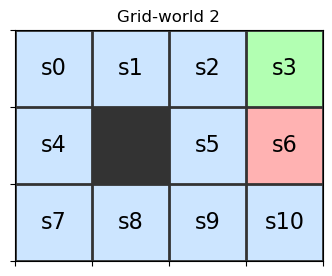

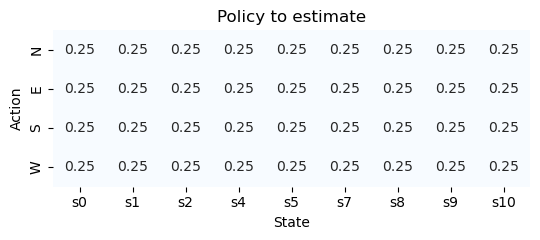

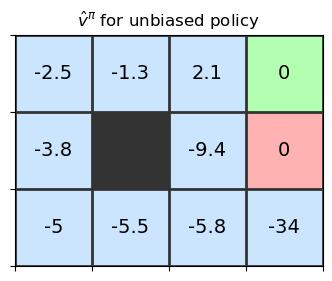

In [2]:
gw = example_grid_worlds.grid_world2()
# visualise the grid-world
gw.visualise(title="Grid-world 2")

# Create a simulation from the model, this is used by our
# TD algorithm rather than the model itself.
sim = MDPSimulation(gw)
num_episodes=10
gamma = 0.9
alpha=0.1

# Create an initial policy for the learning
unbiased_policy = get_unbiased_policy(
        sim.num_states, sim.num_actions)
# Visualise the policy
plot_policy_matrix(
    unbiased_policy, sim, states_as_rows=False,
    title="Policy to estimate")

# Estimate the policy with TD learning
V = temporal_difference_evaluation(
  sim, gamma, alpha, unbiased_policy, num_episodes)
_ = gw.visualise(labels=V, title=r"$\hat{v}^{\pi}$ for unbiased policy")

## TD estimation convergence

As we did for Monte-carlo estimation, we can look at how efficiently TD learns by compareing the value estimates with trusted estimates from Dynamic programming. The plot shows that, as with Monte-carlo evaluation, TD evaluation gives noisy approximations of the dynamic programming result (DP).

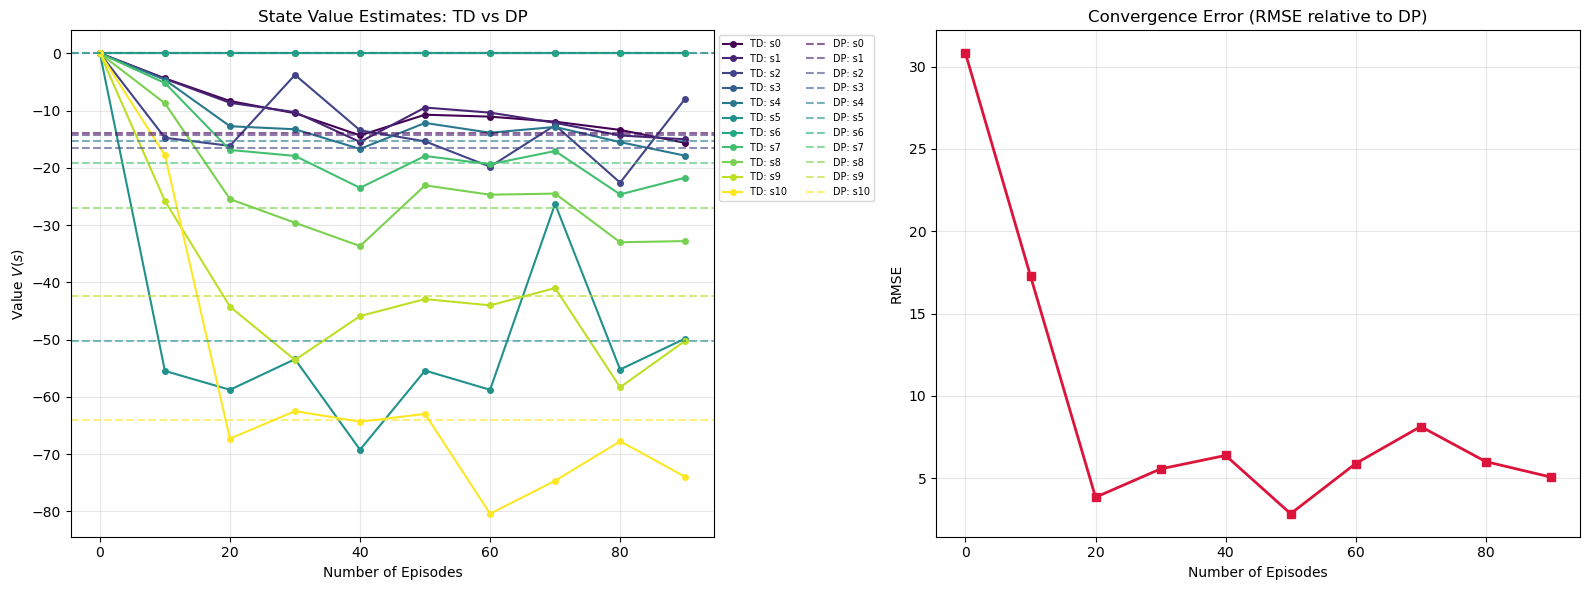

In [11]:
# explore monte carlo evaluation convergence
gamma = 0.9
V_trusted = policy_evaluation(
    sim, gamma, unbiased_policy)
num_episodes_seq = np.arange(0,100,10)

alpha=0.2
all_v_estimates = np.zeros((num_episodes_seq.size, sim.num_states))
for e, num_episodes in enumerate(num_episodes_seq):
    all_v_estimates[e,:] = temporal_difference_evaluation(
        sim, gamma, alpha, unbiased_policy, num_episodes)

line_plot_value_convergence(
    num_episodes_seq, all_v_estimates, V_trusted, sim.state_names,
    experiment_name="TD")

## The effect of $\alpha$

The $\alpha$ (hyper)parameter controls how much the algorithm adapts to each new estimate. High values cause faster convergence but lead to noisier estimates. Lower values converge more slowly but will give less noisy estimates at convergence. The cell below runs the same experiment as above but with a smaller value of $\alpha$. We can see the expected behaviour in terms of slower but smoother convergence. 

In practice, there is nothing stopping you using a higher value of $\alpha$ for early stages and smaller values in the later stages.

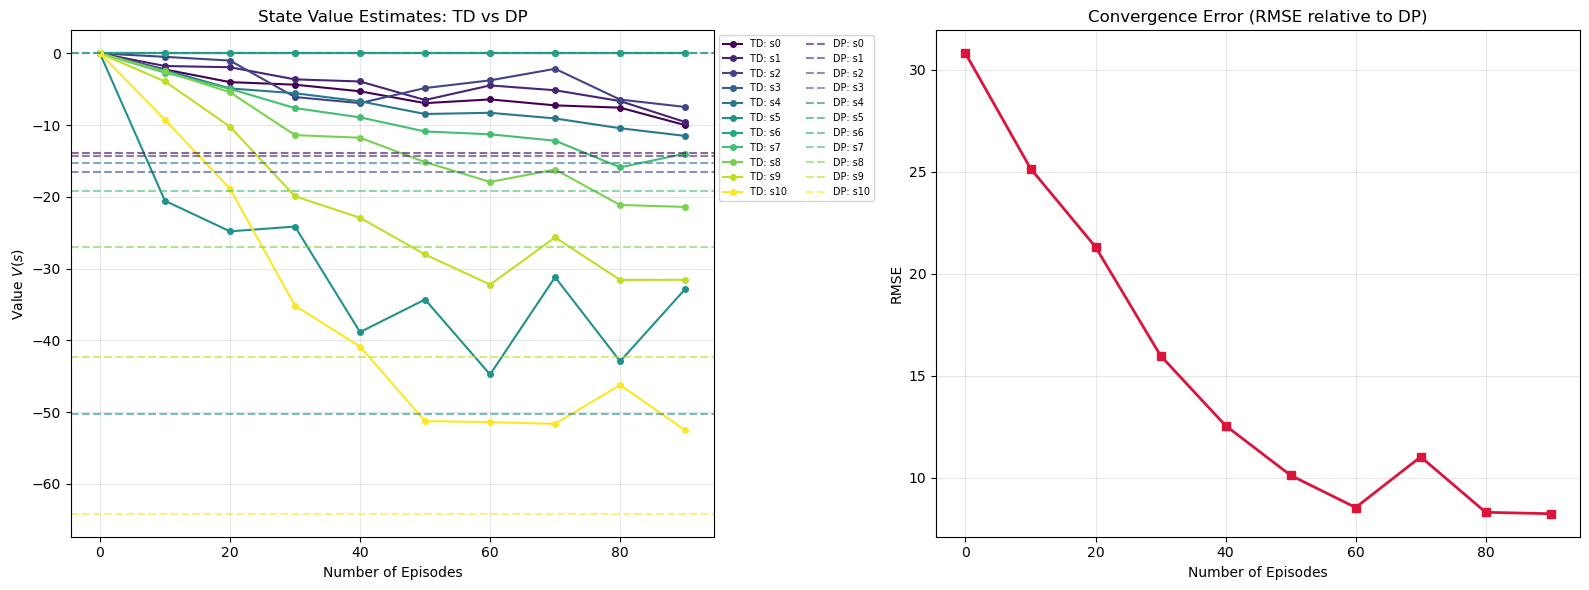

In [12]:
alpha=0.05

all_v_estimates = np.zeros((num_episodes_seq.size, sim.num_states))
for e, num_episodes in enumerate(num_episodes_seq):
    all_v_estimates[e,:] = temporal_difference_evaluation(
        sim, gamma, alpha, unbiased_policy, num_episodes)

line_plot_value_convergence(
    num_episodes_seq, all_v_estimates, V_trusted, sim.state_names,
    experiment_name="TD")

## SARSA

SARSA derives its name from the samples required for each update. To update the state-action value estimate for state and action visited at time-step $t$, we use: state at time $t$, $s_t$, action at time $t$, $a_t$, the subsequent reward $r_{t+1}$, resulting state $s_{t+1}$ and the action following this $a_{t+1}$, giving us the tuple $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$ and hence the name. The update is as follows:
$$
\hat{q}'(S_{t}, A_{t}) \leftarrow \hat{q}(S_{t}, A_{t}) + \alpha
\left[\vphantom{\vest}\right.
\underbrace{R_{t+1} + \gamma\hat{q}(S_{t+1}, A_{t+1})}_{\text{sample}}
-
\underbrace{\hat{q}(S_{t}, A_{t})}_{\text{running est.}}
\left.\vphantom{\vest}\right]
$$

Below, we do just this. One practical trick we can use to improve convergence is to set the initial Q estimates to be higher than their converged values. This ensures that unexplored actions will be taken preferentially some number of times in each visited state. 



Sarsa


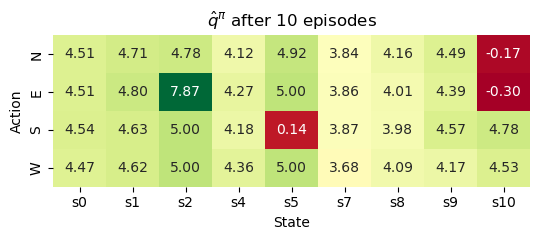

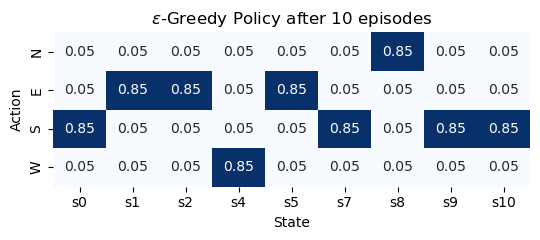

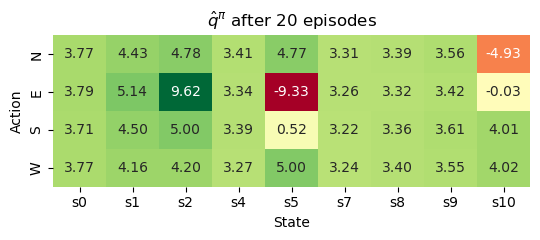

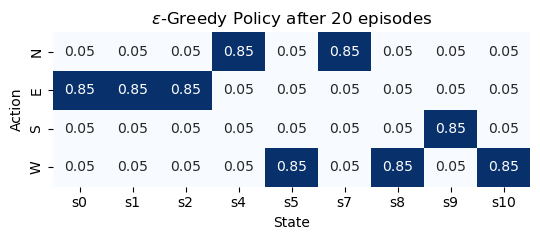

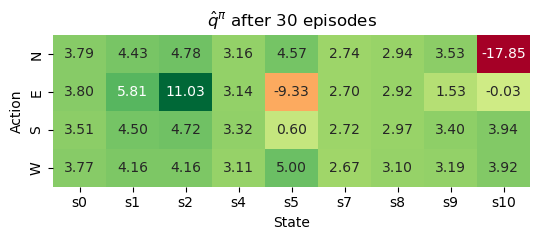

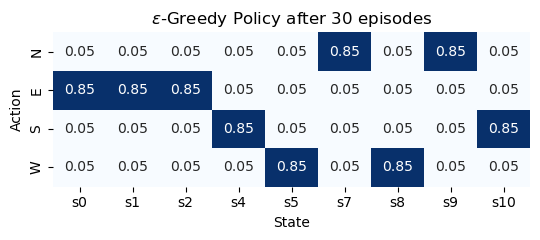

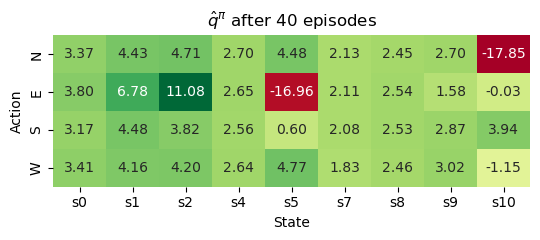

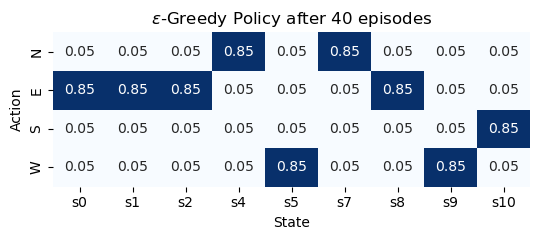

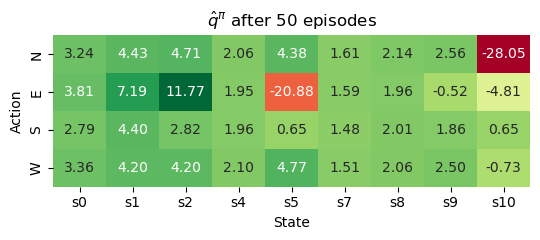

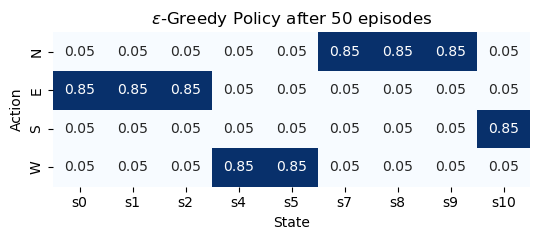

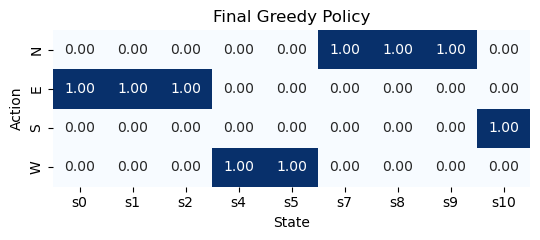

<Figure size 640x480 with 0 Axes>

In [31]:
print("\nSarsa")
# We report the Q-estimates and policy after every window
episodes_per_window=10
num_windows=5
# Set the hyperparameters of the model
gamma = 0.9
alpha=0.05
epsilon=0.2

# An optimistic initial set of Q-values can encourage exploration
Q = 5*np.ones((sim.num_states, sim.num_actions))
episodes_so_far = 0
for window in range(num_windows):
    egreedy_policy, Q = sarsa(
        sim, gamma, alpha=alpha, epsilon=epsilon,
        num_episodes=episodes_per_window, initial_Q=Q)

    episodes_so_far += episodes_per_window
    plot_q_function(
        Q, sim, states_as_rows=False,
       title=r"$\hat{q}$" + f" after {episodes_so_far} episodes")
    plot_policy_matrix(
        egreedy_policy, sim, states_as_rows=False, 
        title=fr"$\varepsilon$-Greedy Policy after {episodes_so_far} episodes")

greedy_policy = get_greedy_policy(Q, absorbing=sim.absorbing)
plot_policy_matrix(
    greedy_policy, sim, states_as_rows=False, 
    title=f"Final Greedy Policy")
plt.tight_layout()

### What have we learned with SARSA

It's easier to see what policy has been learned by labelling the grid-world map with the chosen actions. We do this in the cell below. 

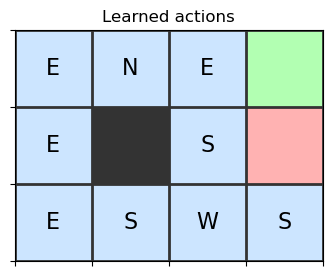

In [30]:
# Convert the dominant action ids into action names.
action_choices = np.array(gw.action_names)[dominant_actions(egreedy_policy)]
# Label locations in the grid-world with best actions. 
_ = gw.visualise(
    labels=action_choices, title="Learned actions", suppress_absorbing=True)


## Issues with on-policy learning

While it is often very effective for learning, SARSA can have issues when the $\epsilon$-greedy control policy causes large fluctuations due to the necessary noise introduced for exploration. In the cell below, we see how SARSA can learn overly safe policies on a grid-world example called "The Cliff" in the Sutton and Barto textbook [SB12].

The issue with this grid-world is that if the agent is in one of the locations just north of the red cells, and walks south, then it will suffer a large negative reward. Put simply, it falls off the cliff. There is no randomness to action outcomes in this world. However, SARSA is forced to introduce randomness into its control policy in order to guarantee exploration. This means when it is close to the cliff and behaving a little randomly, it regularly wanders off the cliff. The safe thing to do then is for SARSA to walk as far north as possible, to stay safe.

When deployed, the agent doesn't behave randomly though, and so this behaviour is undesirable. It doesn't need to play it safe.

absorbing_locs = [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11)]


(<Figure size 1200x400 with 1 Axes>,
 <AxesSubplot:title={'center':'The Cliff'}>)

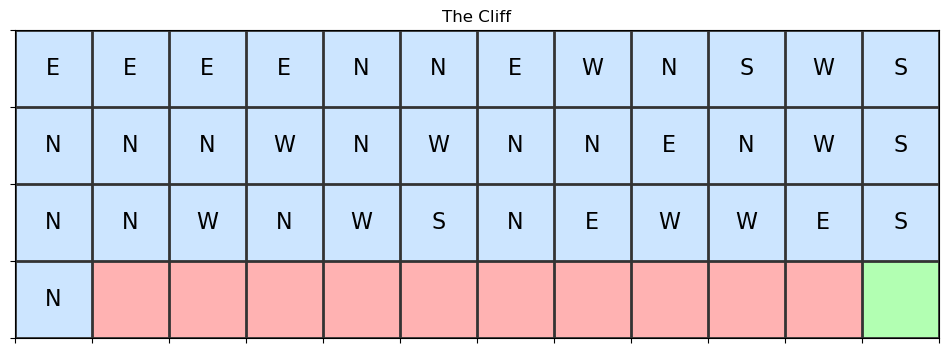

In [49]:
gw_the_cliff = example_grid_worlds.grid_world_the_cliff()

# Create a simulation from the model, this is used by our
# TD algorithm rather than the model itself.
sim_the_cliff = MDPSimulation(gw_the_cliff)
num_episodes=2000
max_steps_per_episode = 40
gamma = 0.9
alpha=0.1
epsilon = 0.1

Q = 5*np.ones((sim_the_cliff.num_states, sim_the_cliff.num_actions))
egreedy_policy, Q = sarsa(
    sim_the_cliff, gamma, alpha=alpha, epsilon=epsilon,
    num_episodes=num_episodes, initial_Q=Q, max_steps=max_steps_per_episode)

# Visualise the cliff and the learned action choices
action_choices = np.array(gw.action_names)[dominant_actions(egreedy_policy)]
gw_the_cliff.visualise(labels=action_choices, title="The Cliff", suppress_absorbing=True)
    

## Q-learning

Q-learning bases state-action estimates on the current best choice of next action in the temporal difference update. To achieve this, it uses an update rule that differs from SARSA only in the second action used. This update is as follows:
$$
  \hat{q}(S_{t}, A_{t})
  \leftarrow \hat{q}(S_{t}, A_{t}) +
  \alpha \left[R_{t+1}+\gamma\max_{a}\hat{q}(S_{t+1},a) - \hat{q}(S_{t},A_{t})\right]
$$

In the context of "The Cliff" this means that when walking along near the edge of the cliff it can behave randomly (recklessley) during training but will update the value estimate based on what would have happened had it chosen the greedy action. The cell below shows q-learning applied to our cliff grid-world. 



(<Figure size 1200x400 with 1 Axes>,
 <AxesSubplot:title={'center':'The Cliff'}>)

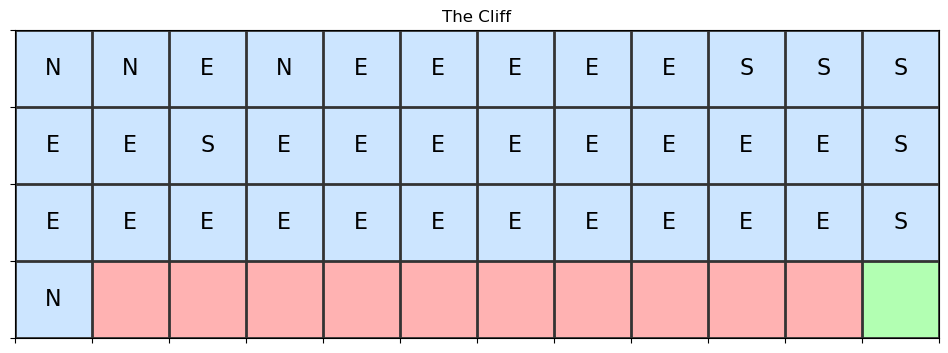

In [48]:

num_episodes=1000
max_steps_per_episode = 40
gamma = 0.9
alpha=0.1
epsilon = 0.15

Q = 5*np.ones((sim_the_cliff.num_states, sim_the_cliff.num_actions))
egreedy_policy, Q = q_learning(
    sim_the_cliff, gamma, alpha=alpha, epsilon=epsilon,
    num_episodes=num_episodes, initial_Q=Q, max_steps=max_steps_per_episode)

action_choices = np.array(gw.action_names)[dominant_actions(egreedy_policy)]
gw_the_cliff.visualise(labels=action_choices, title="The Cliff", suppress_absorbing=True)
    

## Summary and reflection

In this notebook, you have:
* Run temporal difference learning and observed the convergence for different values of $\alpha$
* Run SARSA on a small grid-world and seen it learn within episode
* Observed issues with SARSA in the presence of high fluctuations in return induced by a noisy control policy
* Run Q-learning on the same domain and seen this addresses these issues
